# **📊 Retail Sales Prediction with ML**

## **Notebook Overview**
In this notebook, we will:
1. Load and inspect the retail sales dataset
2. Check data types, missing values, and summary statistics
3. Visualize important patterns in the data
4. Create useful features from the transaction data
5. Build a machine learning model to predict **sales_amount**
6. Evaluate the model using common regression metrics
7. Write a conclusion based on the results

## **Goal**
The goal of this notebook is to predict the **sales amount** of each transaction using the available features.

## **What makes this notebook useful?**
- Easy to understand for beginners
- Includes visualizations for better data understanding
- Uses simple feature engineering
- Builds a strong regression model with good performance
- Ends with a clear conclusion

## **1.Import Libraries**

In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## **2.Load Dataset**

In [2]:
# 2. Load the dataset
df = pd.read_csv("/kaggle/input/datasets/noopurbhatt/retail-sales-dataset/retail_sales_dataset.csv")

## **3.Basic Information**

In [3]:
# 3. Basic inspection
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Info:")
display(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (120000, 17)

First 5 rows:


,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central



Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       

None


Missing Values:
transaction_id        0
transaction_date      0
customer_id           0
customer_gender       0
customer_age_group    0
customer_segment      0
product_id            0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

Summary Statistics:


,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


## **4. Convert Date Column**

In [4]:
# 4. Convert date column
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")


## **5.Feature Engineering**

In [5]:
# 5. Basic feature engineering
# These features help the model learn the sales pattern better
df["gross_sales"] = df["quantity"] * df["unit_price"]
df["discount_amount"] = df["gross_sales"] * (df["discount_pct"] / 100)

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day"] = df["transaction_date"].dt.day
df["day_of_week"] = df["transaction_date"].dt.dayofweek

## **6.Visualization**

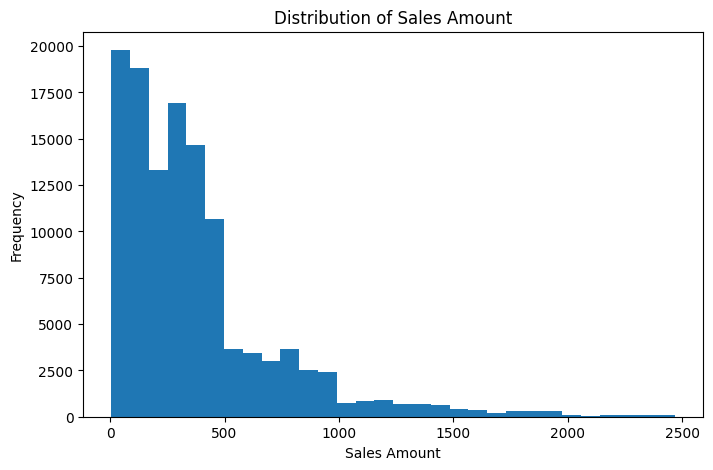

In [6]:
# 6. Visualizations
plt.figure(figsize=(8, 5))
plt.hist(df["sales_amount"], bins=30)
plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

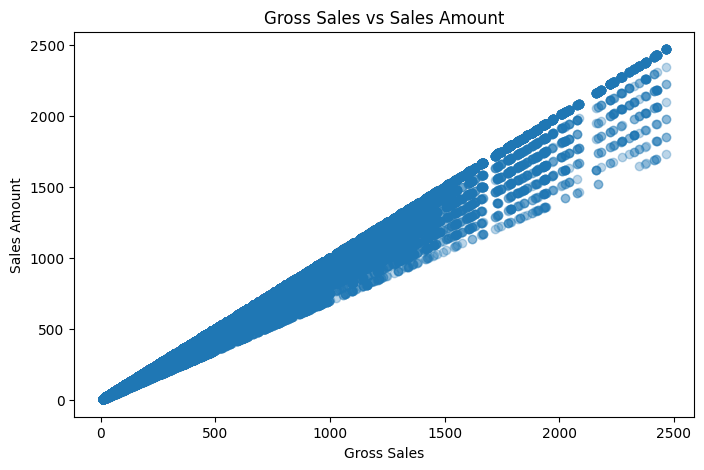

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df["gross_sales"], df["sales_amount"], alpha=0.3)
plt.title("Gross Sales vs Sales Amount")
plt.xlabel("Gross Sales")
plt.ylabel("Sales Amount")
plt.show()

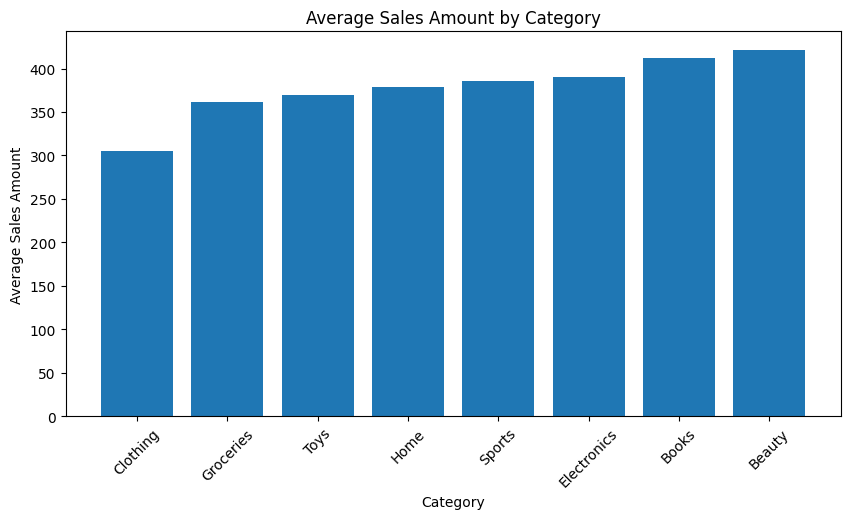

In [8]:
category_sales = df.groupby("category")["sales_amount"].mean().sort_values()

plt.figure(figsize=(10, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Average Sales Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Sales Amount")
plt.xticks(rotation=45)
plt.show()

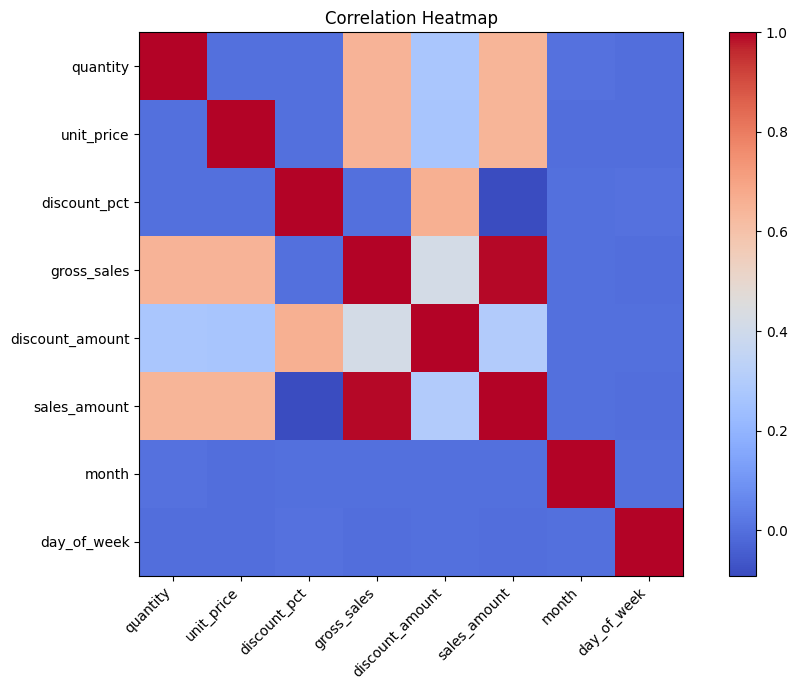

In [9]:
# Correlation heatmap using matplotlib only
numeric_cols = ["quantity", "unit_price", "discount_pct", "gross_sales", "discount_amount", "sales_amount", "month", "day_of_week"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## **7.Feature Selection**

In [10]:
# 7. Prepare data for machine learning
# Sales amount is strongly related to gross sales and discount amount,
# so these engineered features help the model perform very well.

features = ["gross_sales", "discount_amount", "quantity", "unit_price", "discount_pct"]
X = df[features]
y = df["sales_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **8.Model Training**

In [11]:
# 8. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## **9.Predictions**

In [12]:
# 9. Predictions
y_pred = model.predict(X_test)

## **10.Evaluation**

In [13]:
# 10. Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance")
print("-" * 30)
print(f"R2 Score : {r2:.6f}")
print(f"MAE      : {mae:.6f}")
print(f"RMSE     : {rmse:.6f}")


Model Performance
------------------------------
R2 Score : 1.000000
MAE      : 0.000946
RMSE     : 0.001801


## **11.Scatter Plot**

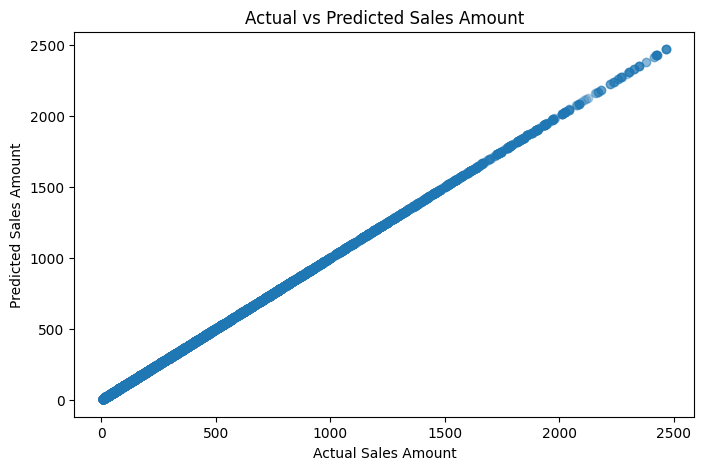

In [14]:
# 11. Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.title("Actual vs Predicted Sales Amount")
plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")
plt.show()

# **Conclusion**
---
- The model predicts sales_amount very accurately.
- The strongest features are gross_sales and discount_amount.
- This shows that sales amount is mainly driven by quantity, unit price, and discount.
- The notebook also includes visualizations to help understand the dataset better.

## **Why R2 Score is 1.0?**
The Linear Regression model achieved an R² score close to 1.0,
which indicates extremely accurate predictions.

This happened because the target variable 'sales_amount'
is strongly dependent on features such as:
- quantity
- unit_price
- discount percentage

The engineered features 'gross_sales' and 'discount_amount'
helped the model capture the exact mathematical relationship.

## **Key Learnings from this notebook:**
1. Data visualization helps understand sales behavior.
2. Feature engineering can significantly improve model performance.
3. Linear Regression performs very well when variables have
   strong linear relationships.
4. Evaluation metrics like R², MAE, and RMSE are important
   for measuring model accuracy.

Overall, this notebook demonstrates a complete beginner-friendly
machine learning workflow from data analysis to prediction.
